Informationen zum Datensatz:
> holidays.csv – Informationen über nationale und lokale Feiertage, die die Verkäufe beeinflussen können
> oil.csv – tägliche Ölpreise, die die Wirtschaftstätigkeit und das Verbraucherverhalten beeinflussen können
> stores.csv – Metadaten über die Filialen (Standort, Typ, Cluster usw.). In diesem Projekt ist nur Filiale 44 relevant.
> times_series.csv – tägliche Verkaufszahlen (Stückzahlen)

> Die Gehälter im öffentlichen Dienst werden alle zwei Wochen am 15. und am letzten Tag des Monats ausgezahlt. Die Supermarktverkäufe könnten davon beeinflusst werden.

# Anfang
## Daten einlesen

In [1]:
import pandas as pd
from fontTools.merge import Merger
from scipy.special.cython_special import bei
from statsmodels.tsa.holtwinters import HoltWintersResults

path = '../Data/Raw/'

holidays = pd.read_csv(path + 'holidays.csv')
oil = pd.read_csv(path + 'oil.csv')
stores = pd.read_csv(path + 'stores.csv')
timeseries = pd.read_csv(path + 'timeseries.csv')

In [2]:
holidays = pd.DataFrame(holidays)
oil = pd.DataFrame(oil)
stores = pd.DataFrame(stores)
timeseries = pd.DataFrame(timeseries)

In [3]:
timeseries

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0
...,...,...
447,2014-03-27,328.0
448,2014-03-28,523.0
449,2014-03-29,647.0
450,2014-03-30,599.0


## Spalte mit Datum formatieren

In [4]:
df = timeseries
df.info()
print()

# konvertiert eine Spalte in ein echtes Datums-/Zeitformat
# Warum nötig? Wenn du eine CSV einliest, erkennt pandas Datumsspalten oft als einfachen Text (string).
# ... Mit pd.to_datetime() wird daraus ein richtiges Datum — erst dann kannst du damit rechnen.
df['date'] = pd.to_datetime(df['date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        452 non-null    object 
 1   unit_sales  452 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.2+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        452 non-null    datetime64[ns]
 1   unit_sales  452 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 7.2 KB


## Datum als Index setzen

In [5]:
df.set_index('date', inplace=True)  # Set 'date' as the index
df.head()

,unit_sales
date,
2013-01-02,582.0
2013-01-03,310.0
2013-01-04,338.0
2013-01-05,654.0
2013-01-06,979.0


# EDA
## Datensatz visualisieren

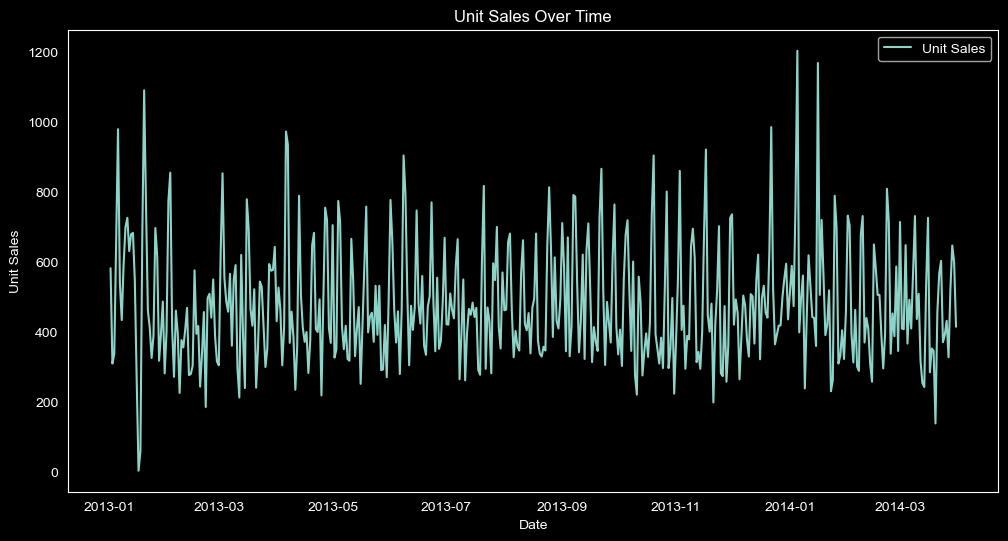

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['unit_sales'], label='Unit Sales')
plt.title('Unit Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.grid(False) # Gitternetz entfernen
plt.show()

## Outlier Detection via Z-Score

In [7]:
# (1) Calculate z-scores to identify outliers
# => Bei einem Z-Score > 3 (bzw. < -3) spricht man typischerweise von Ausreißern

from scipy import stats
import numpy as np

z_scores = stats.zscore(df['unit_sales'])
z_scores_BETRAG = np.abs(z_scores)
outliers = df[z_scores_BETRAG > 3]
outliers

,unit_sales
date,
2013-01-20,1090.0
2014-01-05,1203.0
2014-01-16,1168.0


### Eigene Spielereien

In [8]:
# (2) Add Z-Scores to df
df_outliers = df.copy()
df_outliers["Z-Score"] = z_scores   # the raw array/Series, not the DataFrame
df_outliers["BETRAG_Z-Score"] = z_scores_BETRAG   # the raw array/Series, not the DataFrame

# (3) Add ...
outlier_threshold = 3

df_outliers["Outlier threshold"] = outlier_threshold

df_outliers["Status"] = np.where(
    df_outliers["BETRAG_Z-Score"] > outlier_threshold,
    "Outlier",
    "OK"
)

df_outliers["n Outliers"] = (df_outliers["Z-Score"].abs() >= 3).sum()

# (3) Ordnen
df_outliers = df_outliers.sort_values("BETRAG_Z-Score", ascending=False).head(10)

# (4) Ansehen
print(f"Number of outliers detected: {len(df_outliers[df_outliers['Status'] == 'Outlier'])}")
print()
df_outliers.head(10)

Number of outliers detected: 3



,unit_sales,Z-Score,BETRAG_Z-Score,Outlier threshold,Status,n Outliers
date,,,,,,
2014-01-05,1203.0,4.236193,4.236193,3,Outlier,3
2014-01-16,1168.0,4.031096,4.031096,3,Outlier,3
2013-01-20,1090.0,3.574022,3.574022,3,Outlier,3
2013-12-22,985.0,2.958730,2.958730,3,OK,3
2013-01-06,979.0,2.923570,2.923570,3,OK,3
2013-04-06,972.0,2.882551,2.882551,3,OK,3
2013-01-17,4.0,-2.789855,2.789855,3,OK,3
2013-04-07,936.0,2.671594,2.671594,3,OK,3
2013-11-17,921.0,2.583695,2.583695,3,OK,3


In [9]:
# => Es gibt eiegntlich kaum starke Ausreißer
# Generell: Extrem hohe Verkäufe bestimmter Artikel an einzelnen Tagen können besondere Ereignisse, Promotions oder Datenfehler anzeigen.

## Missing Values (MVs)

In [10]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values

unit_sales    0
dtype: int64

In [12]:
pd.date_range(start=df.index.min(), end=df.index.max())

DatetimeIndex(['2013-01-02', '2013-01-03', '2013-01-04', '2013-01-05',
               '2013-01-06', '2013-01-07', '2013-01-08', '2013-01-09',
               '2013-01-10', '2013-01-11',
               ...
               '2014-03-22', '2014-03-23', '2014-03-24', '2014-03-25',
               '2014-03-26', '2014-03-27', '2014-03-28', '2014-03-29',
               '2014-03-30', '2014-03-31'],
              dtype='datetime64[ns]', length=454, freq='D')

In [13]:
# Check if all days are present
date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq="D")
missing_dates = date_range.difference(df.index)
missing_dates

DatetimeIndex(['2013-12-25', '2014-01-01'], dtype='datetime64[ns]', freq=None)

In [14]:
# wie oben zu sehen fehlen 2 Tage: 25.12.13 und 1.1.14
# diese beiden Tage sollen nun:
## (a) in Datensatz integriert werden
## (b) Werte zugeordnet werden

### Fehlende Tage ergaenzen

In [15]:
df = df.reindex(date_range)
df

,unit_sales
2013-01-02,582.0
2013-01-03,310.0
2013-01-04,338.0
2013-01-05,654.0
2013-01-06,979.0
...,...
2014-03-27,328.0
2014-03-28,523.0
2014-03-29,647.0
2014-03-30,599.0


### Fill missing unit_sales with forward fill

In [16]:
df['unit_sales'] = df['unit_sales'].ffill()

## Summary Statistics

In [17]:
summary_stats = df['unit_sales'].describe()
summary_stats

count     454.000000
mean      479.740088
std       170.560195
min         4.000000
25%       358.500000
50%       443.500000
75%       576.750000
max      1203.000000
Name: unit_sales, dtype: float64

## Seasonal Decomposition

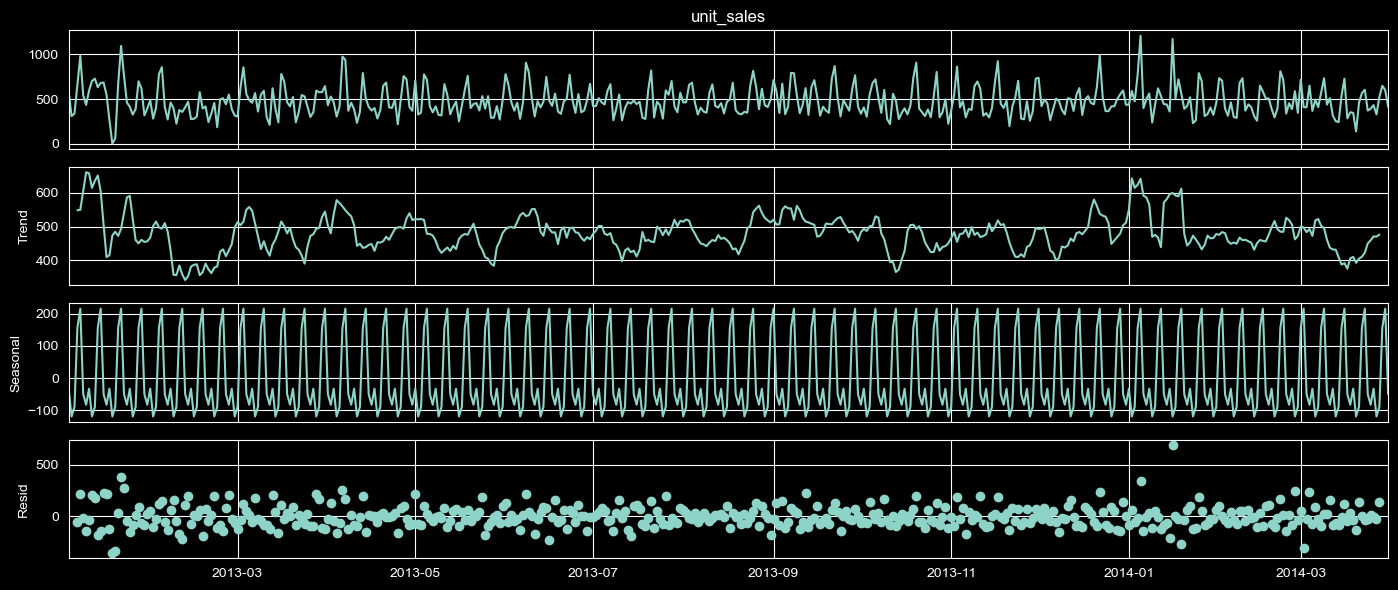

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set frequenc to daily
# This is done for seasonal decomposition to infere seasonal patterns
df = df.asfreq('D')

# Perform seasonal decomposition
decomposition = seasonal_decompose(df['unit_sales'], model='additive')

# Plotting
fig = decomposition.plot()
fig.set_size_inches(14, 6)  # (Breite, Höhe)
plt.tight_layout()
plt.show()

### Interpretation

- => Trend + seasonal + residual = oberste plot (Sprich der oberste Plot setzt sich additativ aus den 3 darunter zusammen)

- Trend:
    - Time Series schwankt zwischen 342 und 661
    - kein systematisches Steigen oder Fallen, sondern pendelt um einen stabilen Mittelwert
    - → kein Trend

- Saisonalität:
    - regelmäßiges, wöchentliches Muster

- Residual:
    - zufälliges Rauschen ohne erkennbares Muster → unauffällig

- Fazit:
    - wöchentliche Saisonalität ohne Trend



### Nochmal anders

In [19]:
from statsmodels.tsa.seasonal import STL

# Falls in deinen Daten Tage fehlen (Lücken), werden diese als Zeilen mit NaN eingefügt. STL und andere Zeitreihenmodelle brauchen eine lückenlose, gleichmäßige Zeitreihe ohne Sprünge im Index.
#sales_by_date = sales_by_date.asfreq('D')
sales_by_date = df.asfreq('D')

# STL decomposition
stl = STL(sales_by_date, period=7)  # again, adjust period based on your seasonality
res = stl.fit()

# Calculate strength of trend and seasonality
# Based on Hyndman’s definition: Strength = 1 - (variance of remainder / variance of (component + remainder))
import numpy as np

trend_strength = 1 - (np.var(res.resid) / np.var(res.trend + res.resid))
seasonal_strength = 1 - (np.var(res.resid) / np.var(res.seasonal + res.resid))

print(f"Strength of Trend: {trend_strength:.2f}")
print(f"Strength of Seasonality: {seasonal_strength:.2f}")

Strength of Trend: 0.29
Strength of Seasonality: 0.70


Faustregel (Hyndman):
- < 0.4 → schwach
- 0.4 – 0.6 → moderat
- > 0.6 → stark

ALSO in meinen Daten:
- 0.29 => schwachter Trend
- 0.70 => starke Saisonalität


## Stationarität

Nicht-stationäre Daten characterisiert durch:
- wachsender Trend
- und/oder sich verändernde Schwankungen
- und/oder wiederkehrende saisonale Muster

### Visuelle Überprüfung 1
#### Durchführung

In [20]:
df.head(4)

,unit_sales
2013-01-02,582.0
2013-01-03,310.0
2013-01-04,338.0
2013-01-05,654.0


In [21]:
sales_by_date = df.reset_index()
print(sales_by_date.columns.tolist())
print(sales_by_date.head(2))

['index', 'unit_sales']
       index  unit_sales
0 2013-01-02       582.0
1 2013-01-03       310.0


In [22]:
sales_by_date = df.reset_index()
sales_by_date = sales_by_date.rename(columns={"index": "date"})
sales_by_date = sales_by_date.groupby("date", as_index=False)[["unit_sales"]].sum()

print(sales_by_date.head(4))
print("")
print(sales_by_date.info())

        date  unit_sales
0 2013-01-02       582.0
1 2013-01-03       310.0
2 2013-01-04       338.0
3 2013-01-05       654.0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        454 non-null    datetime64[ns]
 1   unit_sales  454 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 7.2 KB
None


In [23]:
df.index.name = "date"
df

,unit_sales
date,
2013-01-02,582.0
2013-01-03,310.0
2013-01-04,338.0
2013-01-05,654.0
2013-01-06,979.0
...,...
2014-03-27,328.0
2014-03-28,523.0
2014-03-29,647.0


In [24]:
df.to_csv("../Data/Processed/cleaned_timeseries.csv", index=True)

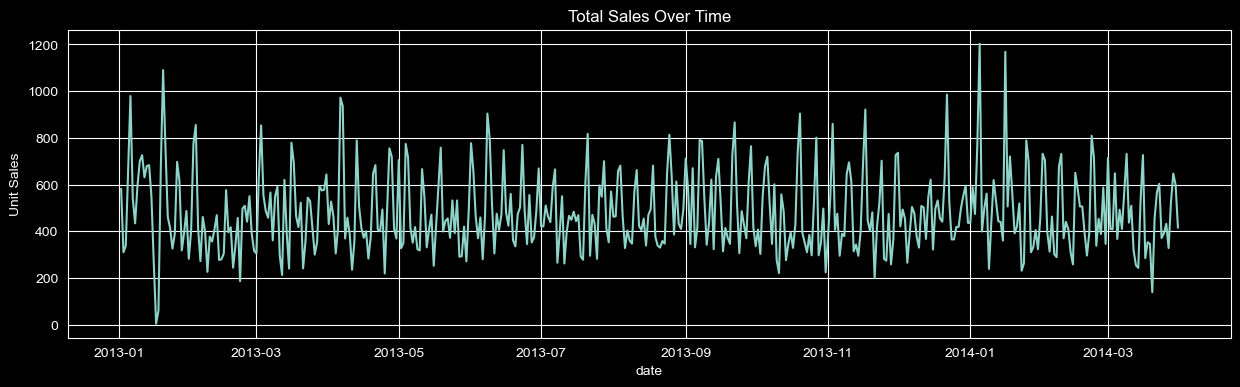

In [25]:
import seaborn as sns

plt.figure(figsize=(15, 4))
sns.lineplot(data=sales_by_date, x="date", y="unit_sales")
plt.title("Total Sales Over Time")
plt.ylabel("Unit Sales")
plt.show()

#### Interpretation

- Kein Trend: Verkaufszahlen pendeln über den gesamten Zeitraum (Jan 2013 – März 2014) um einen stabilen Mittelwert, kein systematisches Steigen oder Fallen.
- Saisonalität: Regelmäßige Schwankungen zwischen ~200 und ~800 deuten auf wöchentliches Muster hin

### Visuelle Überprüfung: Gleitender Mittelwert und Standardabweichung
#### Durchführung

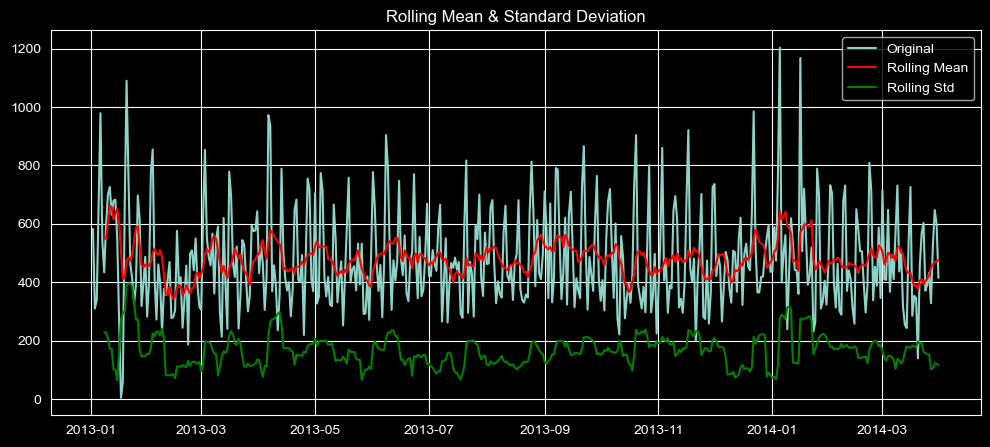

In [26]:
# Window=12 passt zu monatlichen Daten (12 Monate = 1 Jahr), um saisonale Zyklen zu glätten
# Bei täglichen Daten mit wöchentlichen Zyklen machen window = 7 Sinn
# Zum gleitenden Mittelwert gibt in 5.2 noch Theorie zum Verständnis
rolling_mean = sales_by_date["unit_sales"].rolling(window=7).mean()
rolling_std = sales_by_date["unit_sales"].rolling(window=7).std()

plt.figure(figsize=(12,5))
plt.plot(sales_by_date["date"], sales_by_date["unit_sales"], label='Original')
plt.plot(sales_by_date["date"], rolling_mean, label='Rolling Mean', color='red')
plt.plot(sales_by_date["date"], rolling_std, label='Rolling Std', color='green')
plt.title('Rolling Mean & Standard Deviation')
plt.legend()
plt.show()

In [27]:
#df.index.name = "date"
sales_by_date.to_csv("../data/processed/sales_by_date.csv", index=True)

#### INTERPRETATION

ALLGEMEIN:
- Gleitender Mittelwert → hilft, Trends zu erkennen (also veränderter Durchschnitt über Zeit)
- Gleitende Standardabweichung → zeigt veränderliche Varianz (ein Hinweis auf Heteroskedastizität oder Nicht-Stationarität)

- Wenn sowohl gleitender Mittelwert als auch Standardabweichung ungefähr horizontal und stabil sind, ist die Serie wahrscheinlich stationär.


NUN INTERPRETATION DIESER ZEITREIHE HIER:
- Rolling Mean: schwankt zwischen 342 und 661 über den Zeitraum Januar 2013 bis März 2014 → nicht horizontal stabil
- Rolling Std: schwankt zwischen 64 und 396 → sehr instabil, besonders auffällig um Januar 2013 (Ausreißer: 4.0 units am 17.01.2013)
- => Daten sind visuell nicht stationär

### ADF-Test

In [28]:
from statsmodels.tsa.stattools import adfuller

# Perform Augmented Dickey-Fuller test
adf_result = adfuller(df['unit_sales'])
adf_result[1]

np.float64(1.7554305139624077e-05)

In [29]:
from statsmodels.tsa.stattools import adfuller

# Perform Augmented Dickey-Fuller test
adf_result = adfuller(df['unit_sales'])
adf_result_dict = {
    'ADF Statistic': adf_result[0],
    'p-value': adf_result[1],
    'Critical Values': adf_result[4]
}
adf_result_dict

{'ADF Statistic': np.float64(-5.051243167393026),
 'p-value': np.float64(1.7554305139624077e-05),
 'Critical Values': {'1%': np.float64(-3.4454725477848998),
  '5%': np.float64(-2.8682072297316794),
  '10%': np.float64(-2.570321396485665)}}

#### Interpretation

(a) ADF-Test: p-Wert
p < 0.05 → stationär

(b) ADF-Test: ADF-Statistik + Critical Values:
ADF-Statistik < Critical Values (1%, 5%, 10%) → stationär

(c) VORSICHT:
- Daten sind stationär im Sinne der Einheitswurzel. Es liegt also keine Einheitswurzel vor => Schocks klingen ab.
    - Saisonalität ist ein stabiles, vorhersehbares Muster – kein zufälliger Drift. => das sieht die Einheitswurzel NICHT.
- aber Daten sind nicht vollständig stationär wegen vorhandener Saisonalität (siehe visuelle Inspektion)

(d) Was bedeutet das:
- Modelle wie ARIMA setzen Stationarität im Sinne der Einheitswurzel voraus → direkt verwendbar
- Modelle wie SARIMA setzen zusätzlich Behandlung der Saisonalität voraus → besser geeignet

(e) abschließendes Urteil zur Stationarität
- Daten sind laut ADF/Einheitswurzel stationär (kein Drift) => ARIMA kann genutzt werden
- Daten sind allerdings laut visueller Inspektion nicht stationär, da wöchentliche Saisonalität vorhanden => SARIMA besser als ARIMA

## Autocorrelation Analysis
### Durchführung

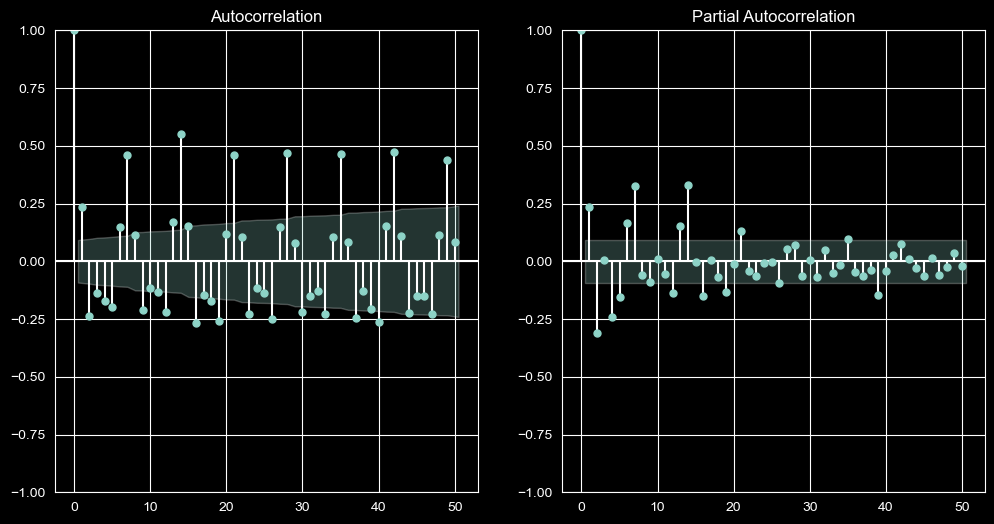

In [30]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(df['unit_sales'], ax=plt.gca(), lags=50)

plt.subplot(122)
plot_pacf(df['unit_sales'], ax=plt.gca(), lags=50)
plt.show()

### Interpretation

- ACF zeigt Saisonalität: regelmäßige Spikes (bei bei Lag 7, 14, 21, ...)  => wöchentliche Saisonalität
- PACF zeigt eher die direkte Autokorrelation ohne Zwischenlags => nützlicher für die Modellwahl (AR-Ordnung), weniger für Saisonalität.

# Save cleaned data

In [31]:
df.index.name = "date"
df.to_csv("../Data/Processed/cleaned_timeseries.csv", index=True)

# For Students: Further EDA and Analysis

In [32]:
"""
Ideas:
- Do holidays impact sales?
- Does the day of the week the impact sales?
- Does the oil price impact sales?
- Get creative and explore the data further! Even if the results show that there is no impact, that is still a useful finding!! We would like mostly to see the thought process no need on statistical perfection (:
"""

'\nIdeas:\n- Do holidays impact sales?\n- Does the day of the week the impact sales?\n- Does the oil price impact sales?\n- Get creative and explore the data further! Even if the results show that there is no impact, that is still a useful finding!! We would like mostly to see the thought process no need on statistical perfection (:\n'

## Zusammenhang Art des Tages und Umsatz
### Holidays in Zeitreihe einfügen

In [33]:
# Wo liegt unser Store (Nr. 44), für den wir die Zeitreihe haben?
stores[stores["store_nbr"] == 44]

# => Quito; Region Pichincha

,store_nbr,city,region
43,44,Quito,Pichincha


In [34]:
print(
    df.index.min(),
    "     ",
    df.index.max()
)

2013-01-02 00:00:00       2014-03-31 00:00:00


### Eigentlich nicht nötig vor left join

In [35]:
# Mich interessieren nur holidays von Ecuador (wo Laden Nr. 44 liegt)
holidays_ecuador = holidays[holidays["locale_name"] == "Ecuador"]

# Das Datum in holidays_ecuador ist noch ein String, muss aber ein Timestamp sein für nachfolgendes filtern
holidays_ecuador["date"] = pd.to_datetime(holidays_ecuador["date"])

# Mich interessieren nur holidays, die innerhalb der Zeitreihe liegen
holidays_ecuador = holidays_ecuador[
    (holidays_ecuador["date"] >= df.index.min()) &
    (holidays_ecuador["date"] <= df.index.max())
]

print(holidays_ecuador.head())
print()
print(holidays_ecuador['locale'].unique())
print()
print(holidays_ecuador['description'].unique())

         date    locale locale_name                         description
42 2013-01-05  National     Ecuador             Recupero puente Navidad
43 2013-01-12  National     Ecuador  Recupero puente primer dia del ano
44 2013-02-11  National     Ecuador                            Carnaval
45 2013-02-12  National     Ecuador                            Carnaval
51 2013-04-29  National     Ecuador                       Viernes Santo

['National']

['Recupero puente Navidad' 'Recupero puente primer dia del ano' 'Carnaval'
 'Viernes Santo' 'Dia del Trabajo' 'Dia de la Madre-1' 'Dia de la Madre'
 'Batalla de Pichincha' 'Primer Grito de Independencia'
 'Independencia de Guayaquil' 'Traslado Independencia de Guayaquil'
 'Dia de Difuntos' 'Independencia de Cuenca' 'Navidad-4' 'Navidad-3'
 'Navidad-2' 'Navidad-1' 'Navidad' 'Navidad+1' 'Primer dia del ano-1'
 'Primer dia del ano']


/var/folders/20/xwv7_w7d3l1d3zzw_1v8hr480000gn/T/ipykernel_5758/107722311.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  holidays_ecuador["date"] = pd.to_datetime(holidays_ecuador["date"])


In [36]:
time_series = df
time_series

,unit_sales
date,
2013-01-02,582.0
2013-01-03,310.0
2013-01-04,338.0
2013-01-05,654.0
2013-01-06,979.0
...,...
2014-03-27,328.0
2014-03-28,523.0
2014-03-29,647.0


In [37]:
time_series_holidays = pd.merge(time_series, holidays_ecuador, on="date", how="left")
time_series_holidays.head(5)

,date,unit_sales,locale,locale_name,description
0,2013-01-02,582.0,NaN,NaN,NaN
1,2013-01-03,310.0,NaN,NaN,NaN
2,2013-01-04,338.0,NaN,NaN,NaN
3,2013-01-05,654.0,National,Ecuador,Recupero puente Navidad
4,2013-01-06,979.0,NaN,NaN,NaN


In [38]:
time_series_holidays['national_holiday'] = np.where(
    time_series_holidays['locale'].isna(),
    'no',
    'yes!'
)

time_series_holidays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              454 non-null    datetime64[ns]
 1   unit_sales        454 non-null    float64       
 2   locale            24 non-null     object        
 3   locale_name       24 non-null     object        
 4   description       24 non-null     object        
 5   national_holiday  454 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 21.4+ KB


### Unnötige Säulen entfernen

In [39]:
time_series_holidays = time_series_holidays.drop(columns=['locale', 'locale_name', 'description'])
time_series_holidays.head(5)

,date,unit_sales,national_holiday
0,2013-01-02,582.0,no
1,2013-01-03,310.0,no
2,2013-01-04,338.0,no
3,2013-01-05,654.0,yes!
4,2013-01-06,979.0,no


### Wochentag/WE ?

In [40]:
# dt.dayofweek zählt ab 0! (0 -> Montag, ..., 6 -> Sontag)
time_series_holidays['day_type'] = np.where(
    time_series_holidays['date'].dt.dayofweek < 5,
    'weekday',
    'weekend'
)

time_series_holidays

,date,unit_sales,national_holiday,day_type
0,2013-01-02,582.0,no,weekday
1,2013-01-03,310.0,no,weekday
2,2013-01-04,338.0,no,weekday
3,2013-01-05,654.0,yes!,weekend
4,2013-01-06,979.0,no,weekend
...,...,...,...,...
449,2014-03-27,328.0,no,weekday
450,2014-03-28,523.0,no,weekday
451,2014-03-29,647.0,no,weekend
452,2014-03-30,599.0,no,weekend


In [41]:
conditions = [
    time_series_holidays['national_holiday'] == 'yes!',
    time_series_holidays['day_type'] == 'weekend'
]

choices = ['holiday', 'weekend']

time_series_day_category = time_series_holidays.copy()
time_series_day_category['day_category'] = np.select(conditions, choices, default='weekday')

time_series_day_category

,date,unit_sales,national_holiday,day_type,day_category
0,2013-01-02,582.0,no,weekday,weekday
1,2013-01-03,310.0,no,weekday,weekday
2,2013-01-04,338.0,no,weekday,weekday
3,2013-01-05,654.0,yes!,weekend,holiday
4,2013-01-06,979.0,no,weekend,weekend
...,...,...,...,...,...
449,2014-03-27,328.0,no,weekday,weekday
450,2014-03-28,523.0,no,weekday,weekday
451,2014-03-29,647.0,no,weekend,weekend
452,2014-03-30,599.0,no,weekend,weekend


### Graphischer Vergleich der Tage

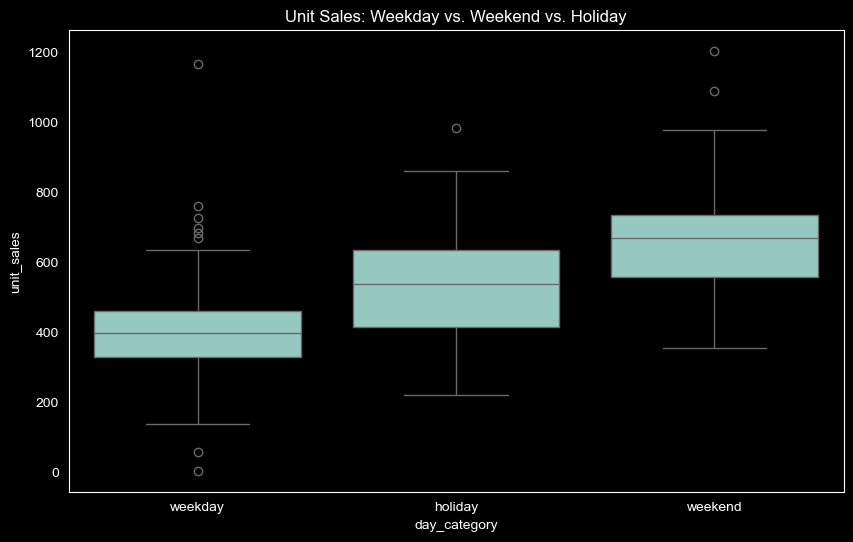

In [42]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=time_series_day_category,
    x='day_category',
    y='unit_sales'
)
plt.title('Unit Sales: Weekday vs. Weekend vs. Holiday')
plt.grid(False)
plt.show()

In [43]:
conditions = [
    (time_series_holidays['national_holiday'] == 'yes!') & (time_series_holidays['day_type'] == 'weekend'),
    (time_series_holidays['national_holiday'] == 'yes!') & (time_series_holidays['day_type'] == 'weekday'),
    time_series_holidays['day_type'] == 'weekend',
    time_series_holidays['day_type'] == 'weekday',
]

choices = [
    'holiday (weekend)',
    'holiday (weekday)',
    'weekend',
    'weekday'
]

time_series_day_categoryV2 = time_series_holidays.copy()
time_series_day_categoryV2['day_category'] = np.select(conditions, choices, default='weekday')

time_series_day_categoryV2.head(4)

time_series_day_categoryV2.to_csv("../Data/Processed/timeseries_holidays.csv", index=True)


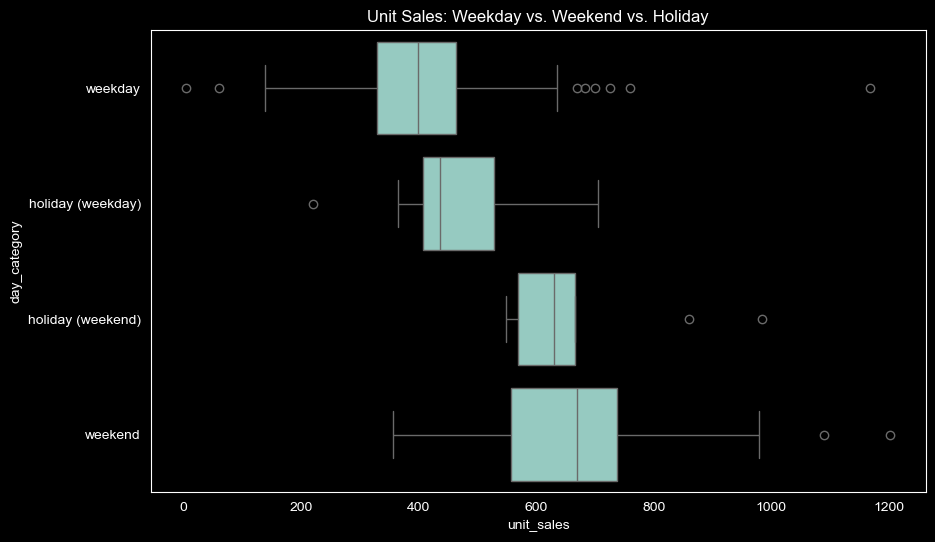

In [44]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=time_series_day_categoryV2,
    x='unit_sales',
    y='day_category',
    # Sortierung nach Median (aufsteigend)
    order=time_series_day_categoryV2.groupby('day_category')['unit_sales'].median().sort_values().index
)
plt.title('Unit Sales: Weekday vs. Weekend vs. Holiday')
plt.grid(False)  # Gitternetz entfernen
plt.show()

> wenn man sich den Trend einfach anschaut ganz oben, dann wird klar, dass es keine große seasonal dependence gibt für unit_sales
> es gibt aber regelmäßige Ausschläge in viel kürzeren Intervallen, vermutlich wöchtentlich
> => rechtfertigt die Untersuchung von unit_sales entsprechend der Kategorien weekday, weekend und holiday

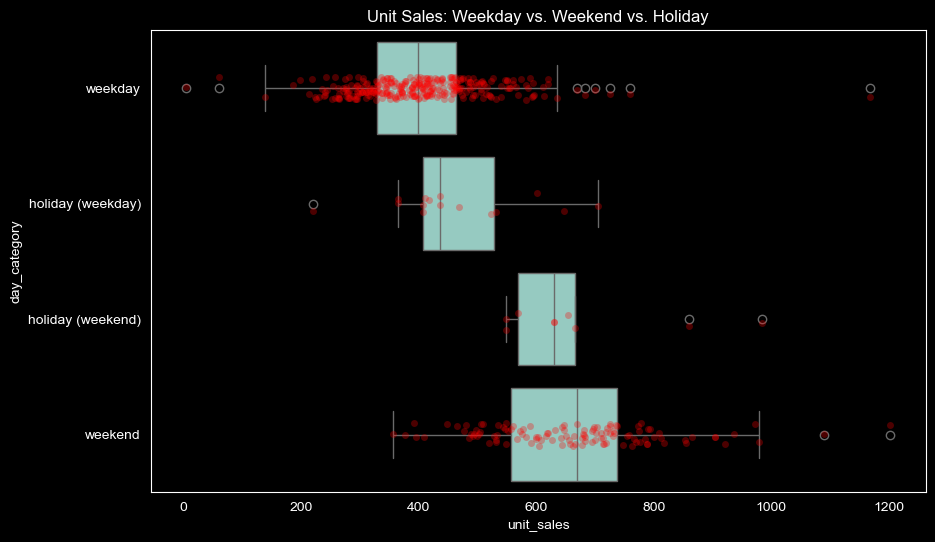

In [45]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=time_series_day_categoryV2,
    x='unit_sales',
    y='day_category',
    # Sortierung nach Median (aufsteigend)
    order=time_series_day_categoryV2.groupby('day_category')['unit_sales'].median().sort_values().index
)
sns.stripplot(
    data=time_series_day_categoryV2,
    x='unit_sales',
    y='day_category',
    color='red',
    alpha=0.3,  # Transparenz
    size=5,     # Punktgröße
    order=time_series_day_categoryV2.groupby('day_category')['unit_sales'].median().sort_values().index
)
plt.title('Unit Sales: Weekday vs. Weekend vs. Holiday')
plt.grid(False)
plt.show()

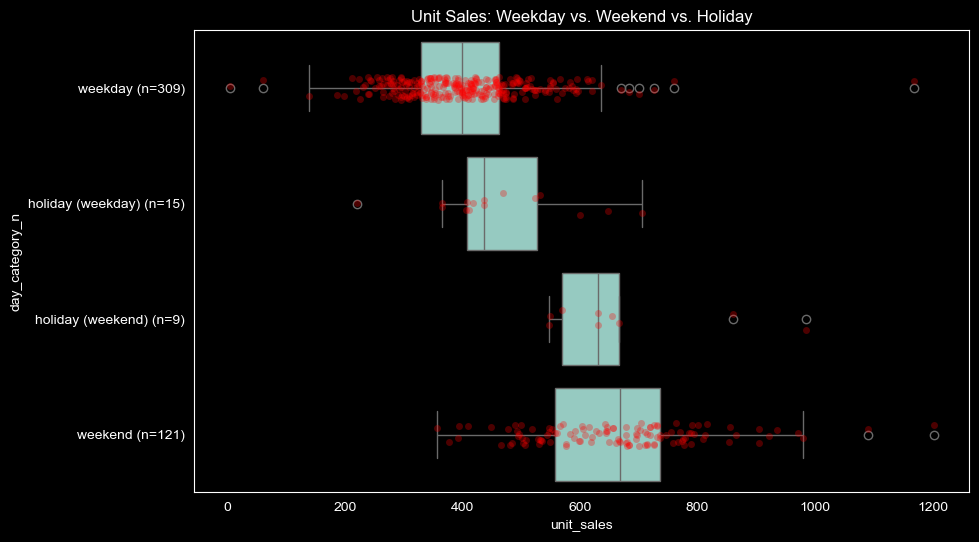

In [46]:
# Anzahl Datenpunkte pro Kategorie berechnen und Label erstellen
n_counts = time_series_day_categoryV2.groupby('day_category')['unit_sales'].count()
time_series_day_categoryV2['day_category_n'] = time_series_day_categoryV2['day_category'].map(
    lambda x: f"{x} (n={n_counts[x]})"
)

#----

order = (time_series_day_categoryV2
    .groupby('day_category_n')['unit_sales']
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=time_series_day_categoryV2,
    x='unit_sales',
    y='day_category_n',
    order=order
)
sns.stripplot(
    data=time_series_day_categoryV2,
    x='unit_sales',
    y='day_category_n',
    color='red',
    alpha=0.3,
    size=5,
    order=order
)
plt.title('Unit Sales: Weekday vs. Weekend vs. Holiday')
plt.grid(False)
plt.show()

### T-Test

In [68]:
import pingouin as pg

t_test_results = pg.pairwise_tests(
    data=time_series_day_categoryV2,
    dv='unit_sales',
    between='day_category',
    parametric=True,  # t-Test
    padjust='bonf'    # Bonferroni-Korrektur
)

t_test_results

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,day_category,holiday (weekday),holiday (weekend),False,True,-3.632267,14.447814,two-sided,2.595499e-03,1.557300e-02,bonf,22.086,-1.555551
1,day_category,holiday (weekday),weekday,False,True,1.875395,15.193759,two-sided,8.008885e-02,4.805331e-01,bonf,1.163,0.529504
2,day_category,holiday (weekday),weekend,False,True,-5.889827,19.089984,two-sided,1.113890e-05,6.683340e-05,bonf,2.979e+05,-1.418032
3,day_category,holiday (weekend),weekday,False,True,5.479232,8.273540,two-sided,5.235322e-04,3.141193e-03,bonf,9.283e+04,2.386615
4,day_category,holiday (weekend),weekend,False,True,0.241296,9.136217,two-sided,8.146540e-01,1.000000e+00,bonf,0.338,0.085721
5,day_category,weekday,weekend,False,True,-18.013978,182.105414,two-sided,2.554674e-42,1.532804e-41,bonf,5.312e+50,-2.131511


Interpretation der T-Test Ergebnisse (Bonferroni-korrigiert)
- weekday vs weekend**:                   p<0.001 → stärkster Unterschied
- holiday (weekday) vs weekend:           p<0.001 → signifikant
- holiday (weekend) vs weekday:           p=0.003 → signifikant
- holiday (weekday) vs holiday (weekend): p=0.016 → signifikant

- holiday (weekday) vs weekday: p=0.481 → kein Unterschied
- holiday (weekend) vs weekend: p=1.000 → kein Unterschied

#### FAZIT

> Feiertage verhalten sich wie der jeweilige Tagestyp (Werktag/Wochenende) — kein eigenständiger Feiertagseffekt!
> am Wochenende wird signifikant mehr als in der Woche verkauft

## Einfluß Benzinpreis
### oil: Umwandlung Series in DataFrame

In [48]:
oil.head(4)

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12


In [49]:
oil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB


In [50]:
# Umwandlung in Dataframe
df_oil = pd.DataFrame(oil)

df_oil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB


In [51]:
# Da Datumsformat verloren ging bei Umwandlung nun Wiederherstellung
df_oil['date'] = pd.to_datetime(df_oil['date'])
df_oil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1218 non-null   datetime64[ns]
 1   dcoilwtico  1175 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 19.2 KB


### df_oil: Datum formatieren

In [52]:
time_series_day_categoryV2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              454 non-null    datetime64[ns]
 1   unit_sales        454 non-null    float64       
 2   national_holiday  454 non-null    object        
 3   day_type          454 non-null    object        
 4   day_category      454 non-null    object        
 5   day_category_n    454 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 21.4+ KB


### Time Series für Merge vorbereiten

In [53]:
time_series_day_categoryV2.head(4)

,date,unit_sales,national_holiday,day_type,day_category,day_category_n
0,2013-01-02,582.0,no,weekday,weekday,weekday (n=309)
1,2013-01-03,310.0,no,weekday,weekday,weekday (n=309)
2,2013-01-04,338.0,no,weekday,weekday,weekday (n=309)
3,2013-01-05,654.0,yes!,weekend,holiday (weekend),holiday (weekend) (n=9)


In [54]:
time_series_day_category_oil = time_series_day_categoryV2.copy()

time_series_day_category_oil = time_series_day_category_oil[["date", "unit_sales", "day_category_n"]]
time_series_day_category_oil.head(4)

,date,unit_sales,day_category_n
0,2013-01-02,582.0,weekday (n=309)
1,2013-01-03,310.0,weekday (n=309)
2,2013-01-04,338.0,weekday (n=309)
3,2013-01-05,654.0,holiday (weekend) (n=9)


In [55]:
time_series_day_category_oil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            454 non-null    datetime64[ns]
 1   unit_sales      454 non-null    float64       
 2   day_category_n  454 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 10.8+ KB


### Merge Time Series & df_oil

In [56]:
time_series_day_category_oil = pd.merge(time_series_day_category_oil, df_oil, how='left', on='date')

In [57]:
time_series_day_category_oil.head()

,date,unit_sales,day_category_n,dcoilwtico
0,2013-01-02,582.0,weekday (n=309),93.14
1,2013-01-03,310.0,weekday (n=309),92.97
2,2013-01-04,338.0,weekday (n=309),93.12
3,2013-01-05,654.0,holiday (weekend) (n=9),NaN
4,2013-01-06,979.0,weekend (n=121),NaN


In [58]:
time_series_day_category_oil

,date,unit_sales,day_category_n,dcoilwtico
0,2013-01-02,582.0,weekday (n=309),93.14
1,2013-01-03,310.0,weekday (n=309),92.97
2,2013-01-04,338.0,weekday (n=309),93.12
3,2013-01-05,654.0,holiday (weekend) (n=9),NaN
4,2013-01-06,979.0,weekend (n=121),NaN
...,...,...,...,...
449,2014-03-27,328.0,weekday (n=309),101.25
450,2014-03-28,523.0,weekday (n=309),101.73
451,2014-03-29,647.0,weekend (n=121),NaN
452,2014-03-30,599.0,weekend (n=121),NaN


### Graphische Auswertung

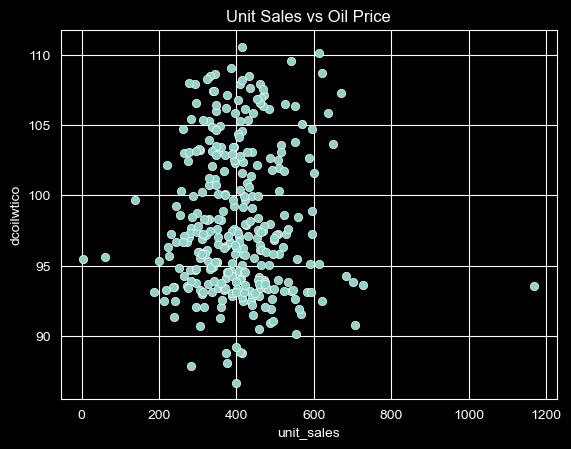

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=time_series_day_category_oil,
    y="dcoilwtico",
    x="unit_sales"
)

plt.title("Unit Sales vs Oil Price")
plt.show()

In [60]:
time_series_day_category_oil["day_category_n"].unique()

array(['weekday (n=309)', 'holiday (weekend) (n=9)', 'weekend (n=121)',
       'holiday (weekday) (n=15)'], dtype=object)

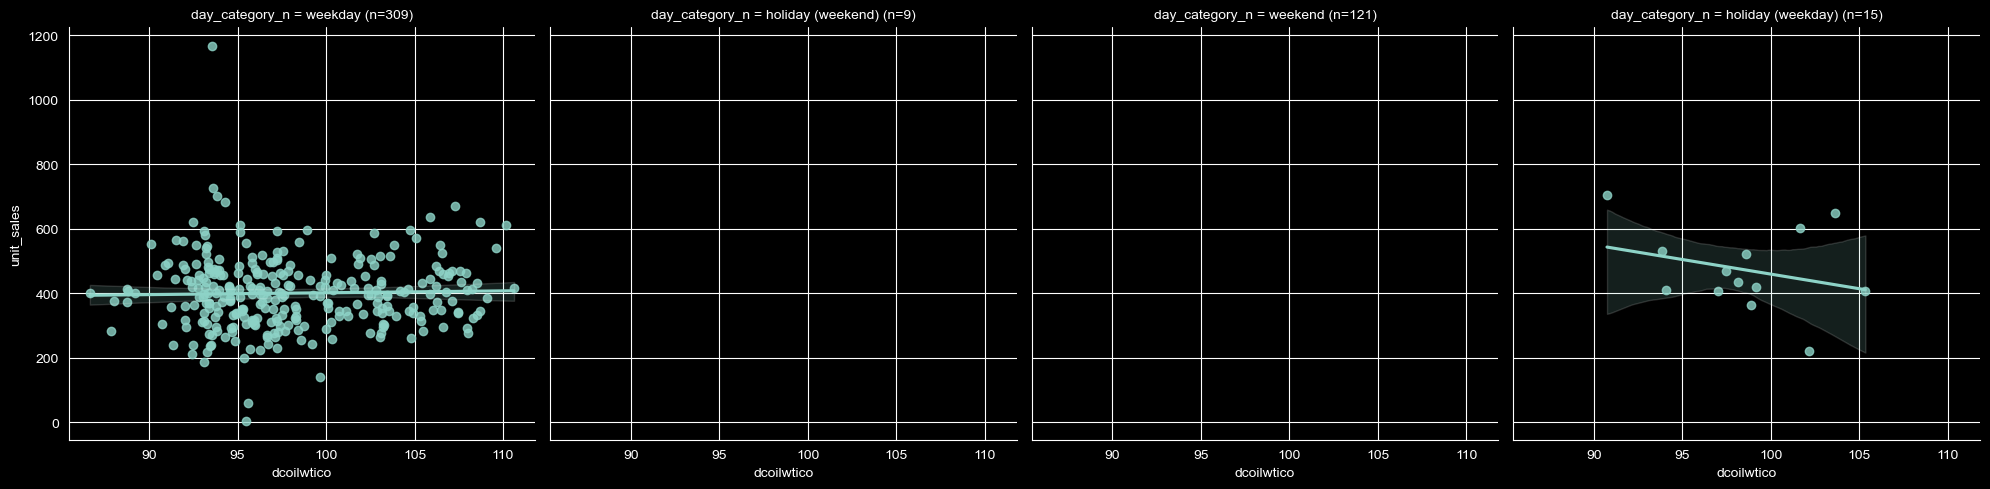

In [61]:
sns.lmplot(
  data=time_series_day_category_oil,
    x="dcoilwtico",
    y="unit_sales",
    col="day_category_n"
)
plt.show()

#plt.title("Unit Sales vs Oil Price")
plt.show()

In [62]:
for cat, group in time_series_day_category_oil.groupby("day_category_n"):
    group = group[["unit_sales", "dcoilwtico"]].dropna()
    if len(group) < 3:
        continue
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        group["unit_sales"], group["dcoilwtico"]
    )
    print(f"\n{cat} (n={len(group)})")
    print(f"  Slope:   {slope:.4f}")
    print(f"  R²:      {r_value**2:.4f}")
    print(f"  p-value: {p_value:.4f}")


holiday (weekday) (n=15) (n=13)
  Slope:   -0.0092
  R²:      0.0833
  p-value: 0.3390

weekday (n=309) (n=300)
  Slope:   0.0013
  R²:      0.0007
  p-value: 0.6412


### FAZIT

Interpretation:
(a) Weekday (n=309)
> Datenpunkte stark gestreut
> optisch kein klarer Trend, bestätigt durch p > 0.05

(b & c) Weekend
> keine Ölpreisdaten fürs Wochenende...

(d) Urlaubstage in der Woche
> Trend: Verkaufszahlen sinken mit stiegenden Ölpreis
> aber breites Konfidenzintervall
> p von 0.34 -> kein statistisch signifikanter Zusammenhang; zudem wird laut R2=0.08 weniger als 10% der Gesamtvarianz erklärt

FAZIT:
> Ein direkter linearer Zusammenhang zwischen Ölpreis und unit_sales ist in keiner Kategorie klar erkennbar

# Aus Learning Journey
## Wochentage einfuegen

In [63]:
time_series_day_category

,date,unit_sales,national_holiday,day_type,day_category
0,2013-01-02,582.0,no,weekday,weekday
1,2013-01-03,310.0,no,weekday,weekday
2,2013-01-04,338.0,no,weekday,weekday
3,2013-01-05,654.0,yes!,weekend,holiday
4,2013-01-06,979.0,no,weekend,weekend
...,...,...,...,...,...
449,2014-03-27,328.0,no,weekday,weekday
450,2014-03-28,523.0,no,weekday,weekday
451,2014-03-29,647.0,no,weekend,weekend
452,2014-03-30,599.0,no,weekend,weekend


In [64]:
# Split the timestamp into model-friendly parts
time_series_day_category['year'] = time_series_day_category['date'].dt.year
time_series_day_category['month'] = time_series_day_category['date'].dt.month
time_series_day_category['day'] = time_series_day_category['date'].dt.day
time_series_day_category['day_of_week'] = time_series_day_category['date'].dt.dayofweek # Monday=0 … Sunday=6

# Lets check the result
time_series_day_category.head(12)


,date,unit_sales,national_holiday,day_type,day_category,year,month,day,day_of_week
0,2013-01-02,582.0,no,weekday,weekday,2013,1,2,2
1,2013-01-03,310.0,no,weekday,weekday,2013,1,3,3
2,2013-01-04,338.0,no,weekday,weekday,2013,1,4,4
3,2013-01-05,654.0,yes!,weekend,holiday,2013,1,5,5
4,2013-01-06,979.0,no,weekend,weekend,2013,1,6,6
5,2013-01-07,541.0,no,weekday,weekday,2013,1,7,0
6,2013-01-08,434.0,no,weekday,weekday,2013,1,8,1
7,2013-01-09,593.0,no,weekday,weekday,2013,1,9,2
8,2013-01-10,700.0,no,weekday,weekday,2013,1,10,3
9,2013-01-11,726.0,no,weekday,weekday,2013,1,11,4


### Mean 7 Smoothing (genau: Lag-1 Rolling Average)

In [65]:
# (1) 7-Mean Smooting
# = Lag-1 Rolling Average
# = verzögerter gleitender Durchschnitt

"""
(1) Shift 1
> damit ich den Wert vom aktuellen Tag nicht mit in Zeitreihe einbeziehe, sonst data leakage
> Rolling-7-Mean für Tag 10 (!ohne Shift) = Mittelwert aus Tag 4, 5, 6, 7, 8, 9, 10 => Tag 10 selbst drin
> Rolling-7-Mean für Tag 10 (mit Shift)   = Mittelwert aus Tag 3, 4, 5, 6, 7, 8, 9  => nur Vergangenheit
"""

time_series_day_category['rolling_mean_7'] = time_series_day_category['unit_sales'].shift(1).rolling(window=7).mean()

time_series_day_category

,date,unit_sales,national_holiday,day_type,day_category,year,month,day,day_of_week,rolling_mean_7
0,2013-01-02,582.0,no,weekday,weekday,2013,1,2,2,NaN
1,2013-01-03,310.0,no,weekday,weekday,2013,1,3,3,NaN
2,2013-01-04,338.0,no,weekday,weekday,2013,1,4,4,NaN
3,2013-01-05,654.0,yes!,weekend,holiday,2013,1,5,5,NaN
4,2013-01-06,979.0,no,weekend,weekend,2013,1,6,6,NaN
...,...,...,...,...,...,...,...,...,...,...
449,2014-03-27,328.0,no,weekday,weekday,2014,3,27,3,422.857143
450,2014-03-28,523.0,no,weekday,weekday,2014,3,28,4,449.857143
451,2014-03-29,647.0,no,weekend,weekend,2014,3,29,5,459.428571
452,2014-03-30,599.0,no,weekend,weekend,2014,3,30,6,470.857143


In [66]:
# (2) Datenvorbereitung für Plotting

df = time_series_day_category.copy()

df_long = df.melt(
    id_vars='date',
    value_vars=['unit_sales', 'rolling_mean_7'],
    var_name='variante',
    value_name='wert',
)

print(df_long["variante"].unique())
print()
df_long.head(10)

['unit_sales' 'rolling_mean_7']



,date,variante,wert
0,2013-01-02,unit_sales,582.0
1,2013-01-03,unit_sales,310.0
2,2013-01-04,unit_sales,338.0
3,2013-01-05,unit_sales,654.0
4,2013-01-06,unit_sales,979.0
5,2013-01-07,unit_sales,541.0
6,2013-01-08,unit_sales,434.0
7,2013-01-09,unit_sales,593.0
8,2013-01-10,unit_sales,700.0
9,2013-01-11,unit_sales,726.0


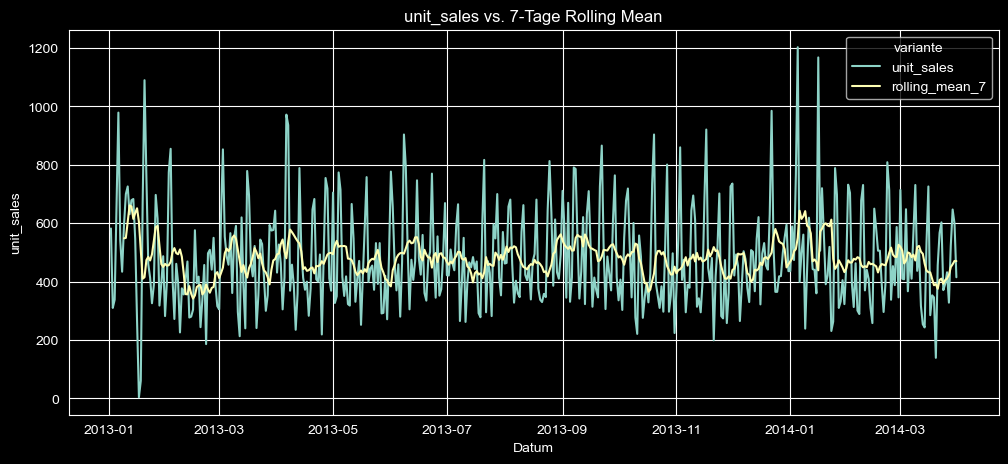

In [67]:
# (3) Plotting

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(
    data=df_long,
    x='date',
    y='wert',
    hue='variante',
    ax=ax
)

ax.set_title('unit_sales vs. 7-Tage Rolling Mean')
ax.set_xlabel('Datum')
ax.set_ylabel('unit_sales')
plt.show()